
### JHG (2025-06-10): Short Jupyter Notebook to run the TARDIS code to output the virtual spectrum. New versions of the code have a malfunctioning relativistic treatment, so the purpose here is to search for *when* the emergent model spectrum changed.


In [1]:

# Downloads tardis_example.yml
!wget -q -nc https://raw.githubusercontent.com/tardis-sn/tardis/master/docs/tardis_example.yml


In [7]:

# loading packages/libraries

import tardis

from tardis.io.configuration import config_reader
from tardis.simulation import Simulation
from tardis.visualization import SDECPlotter

import numpy as np
from astropy import units as u
import matplotlib.pyplot as plt
import math
import os
from glob import glob
import pandas as pd


In [ ]:
from tardis.io.atom_data import download_atom_data
download_atom_data('kurucz_cd23_chianti_H_He')

In [2]:

def _mkdir(newdir):
    """ Creates the required directory for the output files. """
    """works the way a good mkdir should :)
        - already exists, silently complete
        - regular file in the way, raise an exception
        - parent directory(ies) does not exist, make them as well
    """
    if os.path.isdir(newdir):
        pass
    elif os.path.isfile(newdir):
        raise OSError("a file with the same name as the desired " \
                      "dir, '%s', already exists." % newdir)
    else:
        head, tail = os.path.split(newdir)
        if head and not os.path.isdir(head):
            _mkdir(head)
        #print "_mkdir %s" % repr(newdir)
        if tail:
            os.mkdir(newdir)
    return newdir


In [3]:

# toggle relativistic treatment on / off
relativity = True # [True / False]

# set up and run the tardis_example.yml file
tardis_config = config_reader.Configuration.from_yaml("tardis_example.yml")

tardis_config.montecarlo.enable_full_relativity = relativity

# redefining atomic data file since the default one (suffix _latest.h5) doesn't work
tardis_config.atom_data = "kurucz_cd23_chianti_H_He.h5"

simulation = Simulation.from_config(tardis_config, virtual_packet_logging=True)

simulation.run_final()



Number of density points larger than number of shells. Assuming inner point irrelevant
model_isotope_time_0 is not set in the configuration. Isotopic mass fractions will not be decayed and is assumed to be correct for the time_explosion. THIS IS NOT RECOMMENDED!
OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.
/Users/atharva/workspace/code/tardis-main/tardis/tardis/transport/montecarlo/montecarlo_main_loop.py:123: NumbaTypeSafetyWarning:

unsafe cast from uint64 to int64. Precision may be lost.



TqdmHBox(children=(HTML(value='Iterations:', layout=Layout(width='6%')), FloatProgress(value=0.0, layout=Layou…

TqdmHBox(children=(HTML(value='Packets:\u2007\u2007\u2007', layout=Layout(width='6%')), FloatProgress(value=0.…

In [4]:

folder_name_string = "outputs"
filename_string = f"tardis_example_rel={relativity}"

# how to access the virtual spectrum changes in the code in the last ~year, so this line will have to be updated at some point...
# this output file is the file to inspect - we want to know when it changes!
simulation.spectrum_solver.spectrum_virtual_packets.to_ascii(f"{_mkdir(f'{folder_name_string}/dat_files')}/{filename_string}_virtual_spectrum.dat")


<>:14: SyntaxWarning:

invalid escape sequence '\m'

<>:15: SyntaxWarning:

invalid escape sequence '\m'

<>:14: SyntaxWarning:

invalid escape sequence '\m'

<>:15: SyntaxWarning:

invalid escape sequence '\m'

/var/folders/5r/hzj1v37d7nl3gpyk2kt94qb40000gn/T/ipykernel_77856/1005718661.py:14: SyntaxWarning:

invalid escape sequence '\m'

/var/folders/5r/hzj1v37d7nl3gpyk2kt94qb40000gn/T/ipykernel_77856/1005718661.py:15: SyntaxWarning:

invalid escape sequence '\m'



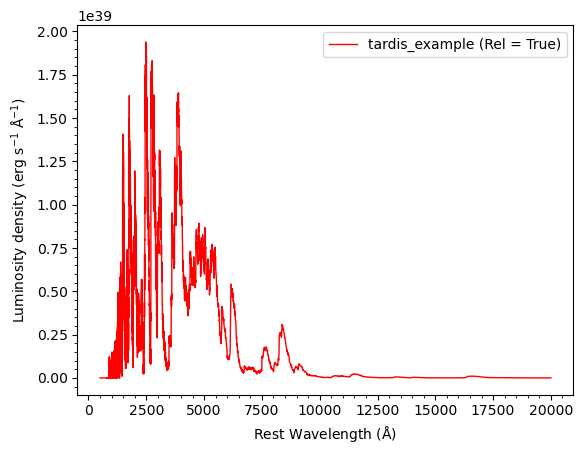

In [8]:

# producing a plot of the spectrum for visual inspection

virtual_spectrum = np.loadtxt(f"{_mkdir(f'{folder_name_string}/dat_files')}/{filename_string}_virtual_spectrum.dat")

plt.plot(virtual_spectrum[:,0], virtual_spectrum[:,1], label=f"tardis_example (Rel = {relativity})", color='red', linewidth=1.0)

# plotting legend
plt.legend(loc='best')

# setting gridlines and tick marks on x and y axes
plt.minorticks_on()

# setting titles for x and y axes
plt.xlabel('Rest Wavelength ($\mathrm{\AA}$)')
plt.ylabel('Luminosity density (erg $\mathrm{s^{-1}}$ $\mathrm{\AA^{-1}}$)')

plt.show()

# plt.savefig(f"{_mkdir(f'{folder_name_string}/spectra')}/{filename_string}_spectrum.pdf", dpi=900, bbox_inches = 'tight')
# plt.close()



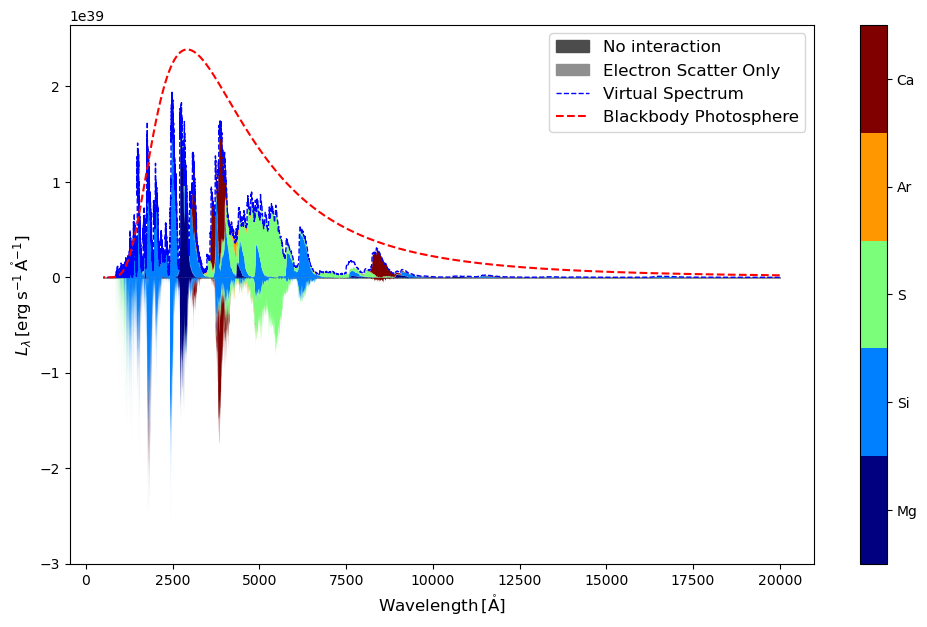

In [9]:

# making an SDEC plot for visual inspection

plotter = SDECPlotter.from_simulation(simulation)
plotter.generate_plot_mpl(nelements=10)

plt.show()

# plt.savefig(f"{_mkdir(f'{folder_name_string}/SDEC')}/{filename_string}_SDEC.png", dpi=900, bbox_inches = 'tight')
# plt.close()
